In [5]:
using Plots 
n_max = 127
n_max2 = Int(round(n_max/2))
# Create single mode displacement and squeezing operators and their compositions algebraically

64

In [6]:
# first generate a and a^\dagger
function make_a_a_dag(n_max)
    a = zeros(n_max+1,n_max+1)
    a_dag = zeros(n_max+1,n_max+1)
    for n in 1:n_max
        a[n,n+1] = sqrt(n)
        a_dag[n+1,n] = sqrt(n)
    end
    return a, a_dag
end
## Test
##a, a_dag = make_a_a_dag(2)

make_a_a_dag (generic function with 1 method)

In [7]:
function make_D(alpha, n_max) # makes a displacement operator 
    a, a_dag = make_a_a_dag(n_max)
    D = exp(alpha*a_dag - conj(alpha)*a)
    return D
end
## Test 
#D = make_D(1,2)
function make_S(z, n_max) # makes a squeezing operator
    a, a_dag = make_a_a_dag(n_max)
    S = exp(0.5*(z*a_dag^2 - conj(z)*a^2))
    return S
end
## Test 
#S = make_S(1,2)
function make_expN(phi, n_max) # makes exp(i/2* phi * (n+1/2))
    a, a_dag = make_a_a_dag(n_max)
    N_2 = a_dag*a
    for n in 1:n_max
        N_2[n,n] += 0.5
    end
    #println(N_2)
    expN = exp(im/2*phi*N_2)
    return expN
end
## Test
expN = make_expN(1,2)

3×3 Matrix{ComplexF64}:
 0.968912+0.247404im       0.0+0.0im            0.0+0.0im
      0.0+0.0im       0.731689+0.681639im       0.0+0.0im
      0.0+0.0im            0.0+0.0im       0.540302+0.841471im

Max. Difference between D_3 and D_1*D_2 is 9.856160834467555e-16


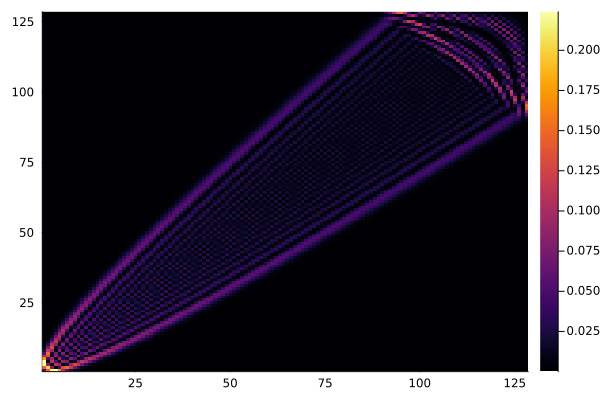

In [8]:
# Displacement composition
function D1_D2(alpha_1, alpha_2)
    # returns the parameters for the composition operator 
    alpha = alpha_1 + alpha_2
    phase = exp(im*imag(alpha_1*conj(alpha_2)))
    return alpha, phase
end
## Test
alpha_1 = 1.2+0.3im
alpha_2 = 0.5+0.1im
alpha_3, phase = D1_D2(alpha_1, alpha_2)
D_1 = make_D(alpha_1, n_max)
D_2 = make_D(alpha_2, n_max)
D_3 = make_D(alpha_3, n_max) * phase
difference = D_3- D_1*D_2
println("Max. Difference between D_3 and D_1*D_2 is $(maximum(abs.(difference[1:n_max2, 1:n_max2])))")
heatmap(abs2.(D_3))

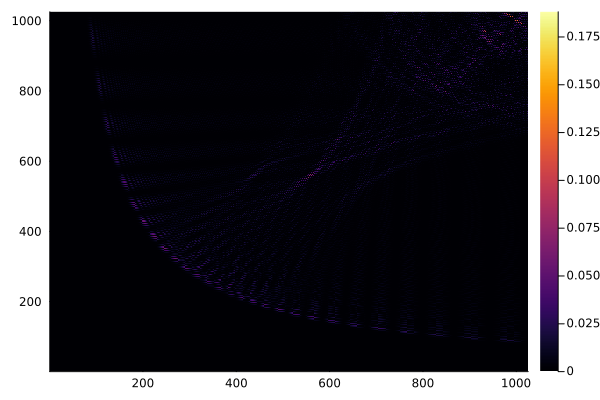

In [42]:
# Now composition of squeezing operators
function S1_S2(z1, z2)
    # returns the parameters for the composition operator 
    r1 = abs(z1)
    r2 = abs(z2)
    phi1 = angle(z1)
    phi2 = angle(z2)
    # Deduce
    eps1 = tanh(r1)*exp(im*phi1)
    eps2 = tanh(r2)*exp(im*phi2)
    eps3 = (eps1 + eps2)/(1 + conj(eps1)*eps2)
    r3 = atanh(abs(eps3))
    phi3 = angle(eps3)
    z3 = r3*exp(im*phi3)
    # For n+1/2 term 
    #theta = 1/im * log((1+eps1*conj(eps2))/(1+conj(eps1)*eps2)) # log not well behaved at zero
    theta = 2 *  angle(1+eps1*conj(eps2))
    return z3, theta
end
# Test 
z1 = 0.7+0.3im
z2 = 0.5+0.1im
n_max = 1024
z3, theta = S1_S2(z1, z2)
S_1 = make_S(z1, n_max)
S_2 = make_S(z2, n_max)
S_3 = make_S(z3, n_max) * make_expN(theta, n_max)
difference = S_3- S_1*S_2
heatmap(abs2.(difference))


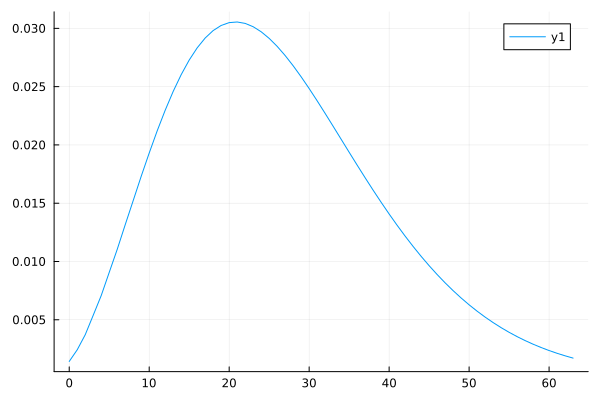

In [26]:
function vacuum_state(n_max)
    state::Vector{ComplexF64} = zeros(n_max+1)
    state[1] = 1.0
    return state
end
# create a squeezed-coherent state D(alpha)S(z)|0>
function make_squeezed_coherent(alpha, z, n_max)
    D = make_D(alpha, n_max)
    S = make_S(z, n_max)
    state = D*S*vacuum_state(n_max)
    return state
end
# Test
alpha = 5.0+0.3im
z = 1.0
state = make_squeezed_coherent(alpha, z, n_max)
plot(0:n_max2-1, abs2.(state[1:n_max2]))

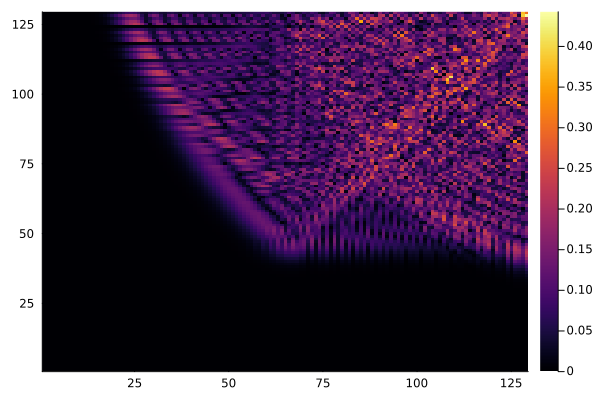

In [63]:
function DS2SD(alpha, z)
    # Exchange D and S from D*S to S*D 
    abs_z = abs(z)
    exp_abs_z = exp(abs_z)
    exp_abs_z_minus = 1/exp_abs_z
    cosh_abs_z = 0.5*(exp_abs_z + exp_abs_z_minus)
    sinh_abs_z = 0.5*(exp_abs_z - exp_abs_z_minus)
    gamma = alpha * cosh_abs_z - conj(alpha) * exp(im*angle(z)) * sinh_abs_z
    return gamma
end
# Test 
n_max = 128
alpha = 5.0+0.2im
z = 0.3+0.2im
gamma = DS2SD(alpha, z)
S = make_S(z, n_max)
DS = make_D(alpha, n_max) * S
SD = S * make_D(gamma, n_max)
heatmap(abs.(SD-DS))

In [69]:
# function to calculate the overlap between two speezed coherent states 
function numerical_overlap_squeezed_coherent(alpha1, z1, alpha2, z2, n_max)
    state1 = make_squeezed_coherent(alpha1, z1, n_max)
    state2 = make_squeezed_coherent(alpha2, z2, n_max)
    overlap = state1'*state2
    return overlap
end
function overlap_squeezed_coherent(alpha1, z1, alpha2, z2)
    # calculate the overlap between two squeezed coherent states SDDS -> SDS -> SD
    alpha, phase = D1_D2(-alpha1, alpha2)
    gamma = DS2SD(alpha, z2)
    z3, theta = S1_S2(-z1, z2)
    exp_theta = exp(im/4*theta)
    alpha = gamma * exp_theta ^2 
    phase *= exp_theta
    # S(z3) * D(alpha)
    # <0|S(z3)D(alpha)|0> * phase = <0|S'(-z3) D'(-alpha)|0> * phase
    # = (<0|D(-alpha)S(-z3)|0>)' * phase
    # in Eq. 2.48 of Agarwals book Quantum optics: beta -> -alpha and \eta -> -z3 and n=0
    phi = angle(-z3)
    exphi = exp(im*phi)
    r = abs(z3)
    tanhr = tanh(r)
    coshr = cosh(r)
    overlap_term = exp(-0.5*abs(alpha)^2 + conj(-alpha)^2 * exphi/2 * tanhr) / sqrt(coshr)
    return conj(overlap_term) * phase
end
# Test
alpha1 = 3.0+0.3im
z1 = 1.0
alpha2 = 5.0+0.2im
z2 = 0.3+0.2im
ovelap = overlap_squeezed_coherent(alpha1, z1, alpha2, z2)
numerical_overlap = numerical_overlap_squeezed_coherent(alpha1, z1, alpha2, z2, n_max)
println("Analytical overlap: $ovelap, Numerical overlap: $numerical_overlap")
println("Difference: $(abs(ovelap-numerical_overlap))")

Analytical overlap: 0.33467369972450817 - 0.42513025636516494im, Numerical overlap: 0.33467369972450745 - 0.42513025636516405im
Difference: 1.1443916996305594e-15


In [9]:
include("squeezed_coherent_states.jl")
# Test 
x = 1.0 + 1.0im
r = abs(x)
theta = angle(x)
alpha = 2.0 + 2.0im
s = 1.2 + 1.2im
ms = alpha*s
pms = (abs2(alpha) + sinh(r)^2)*s
mms = (alpha^2+exp(im*theta)*sinh(2*r)/2)*s 
alpha_fit, r_fit, theta_fit = fit_displaced_squeezed_state(s, ms, mms)
# check the approximations 
#first construct the exact operator expectation values 

(2.0 + 2.0im, 1.4142135623730951, 0.7853981633974485, 0.0)

In [10]:
# operator expectation values 
# define operators a and a' for up to n photons 
function mat_annihilation(n::Int)
    A = zeros(ComplexF64, n+1, n+1)
    for i in 1:n
        A[i, i+1] = sqrt(i)
    end
    return A
end
function mat_creation(n::Int)
    A = zeros(ComplexF64, n+1, n+1)
    for i in 2:n+1
        A[i, i-1] = sqrt(i-1)
    end
    return A
end
function eye(n::Int)
    A = zeros(ComplexF64, n+1, n+1)
    for i in 1:n+1
        A[i, i] = 1.0
    end
    return A
end
function mat_displaced_squeezed_operators(n::Int)
    a = mat_annihilation(n)
    a_prime = mat_creation(n)
    a_mod = a*cosh(r) .+ a_prime*exp(im*theta)*sinh(r) .+ alpha * eye(n)
    a_prime_mod = a_prime*cosh(r) .+ a*exp(-im*theta)*sinh(r) .+ conj(alpha) * eye(n)
    return a_mod, a_prime_mod
end
function matrix_expectation_values(p::Int=1,q::Int=1)
    n = p+q
    a, a_prime = mat_displaced_squeezed_operators(n)
    zero_state = zeros(ComplexF64, n+1)
    zero_state[1] = 1.0
    for i in 1:q
        zero_state = a*zero_state
    end
    for i in 1:p
        zero_state = a_prime*zero_state
    end
    return zero_state[1]
end
# Test 
# compare matrix_expectation_values and displaced_squeezed_state_test
for n in 3:4
    for p in 0:floor(Int, n/2)
        q = n-p
        val = matrix_expectation_values(p, q)
        val2 = displaced_squeezed_state_expectation(alpha_fit, r_fit, theta_fit, val, p, q)
        println("p=", p, " q=", q, " difference of expectation values: ", abs(val .- val2))
    end
end

p=0 q=3 difference of expectation values: 3.552713678800501e-15
p=1 q=2 difference of expectation values: 3.552713678800501e-15
p=0 q=4 difference of expectation values: 2.842170943040401e-14
p=1 q=3 difference of expectation values: 5.859285502108464e-14
p=2 q=2 difference of expectation values: 3.552713678800501e-15
